## YOLOv8 Object Detection Demo

This notebook demonstrates a simple object detection workflow using the YOLOv8 model from the `ultralytics` library.

In [ ]:
# Install necessary libraries
!pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00


After installing the `ultralytics` library, we can import the `YOLO` model and load a pre-trained version. For this demo, we'll use `yolov8n.pt`, which is a nano-sized model, good for quick demonstrations.

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

print('YOLOv8 model loaded successfully!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 model loaded successfully!


Next, we'll download an example image to run our object detection model on. You can replace this with any image URL you like.

In [ ]:
# Download an example image
!wget -q -O test_image.jpg https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg

print('Example image downloaded: test_image.jpg')

Example image downloaded: test_image.jpg


Now, we will run the object detection model on the downloaded image. The `model.predict()` function will detect objects, and we'll save the results, including the annotated image.


image 1/1 /content/test_image.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 330.3ms
Speed: 15.6ms preprocess, 330.3ms inference, 35.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Detected objects: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'ca

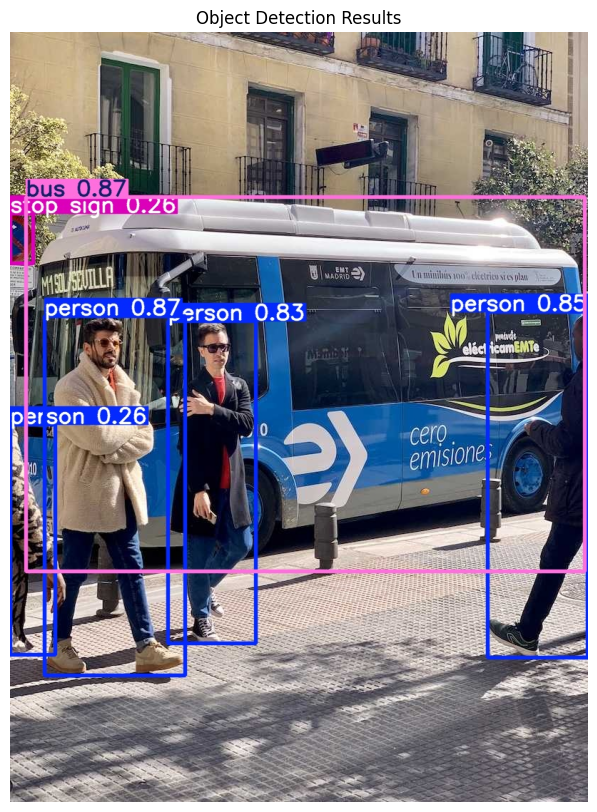

In [ ]:
# Run inference on the image
# The 'save=True' argument saves the annotated image to a 'runs/detect/predict' directory.
results = model.predict('test_image.jpg', save=True, imgsz=640, conf=0.25)

# Display the results (this will show the path to the saved image and print detected objects)
for r in results:
    print(f"Detected objects: {r.names}")
    im_array = r.plot()  # plot a BGR numpy array of predictions
    print(f"Annotated image saved to: {r.save_dir}")

import matplotlib.pyplot as plt
import cv2

# Read the annotated image (YOLOv8 saves it in BGR format)
annotated_image_path = f"{results[0].save_dir}/test_image.jpg"
img_bgr = cv2.imread(annotated_image_path)

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Object Detection Results')
plt.show()

### Interactive Confidence Threshold

Now, let's add an interactive slider to adjust the confidence threshold (`conf`). A higher threshold means the model needs to be more certain about a detection to show it, potentially reducing false positives but also possibly missing some true positives. A lower threshold will show more detections, including less certain ones.

Run the cell below, adjust the slider, and observe how the detected objects change.

In [ ]:
from IPython.display import display, Image
import ipywidgets as widgets
from ultralytics import YOLO
import os

# Reload the model if it's not already loaded (useful if running cells out of order)
if 'model' not in locals():
    model = YOLO('yolov8n.pt')

def run_detection(confidence_threshold):
    # Clear previous prediction runs to avoid clutter
    # This part might need adjustment if you want to keep all runs for later inspection
    # For simplicity, we'll let `save=True` handle incremental directory naming

    # Run inference with the new confidence threshold
    results_live = model.predict(
        'test_image.jpg',
        save=True,
        imgsz=640,
        conf=confidence_threshold,
        project='runs_interactive', # Save to a separate project folder
        name=f'conf_{confidence_threshold:.2f}' # Name the run by confidence
    )

    # Get the path to the annotated image from the latest run
    latest_run_dir = results_live[0].save_dir
    annotated_image_path_live = os.path.join(latest_run_dir, 'test_image.jpg')

    print(f"Confidence Threshold: {confidence_threshold:.2f}")
    for r in results_live:
        names_found = [r.names[int(cls_id)] for cls_id in r.boxes.cls]
        if names_found:
            print(f"Detected objects: {', '.join(set(names_found))}")
        else:
            print("No objects detected.")

    # Display the annotated image
    display(Image(filename=annotated_image_path_live))

# Create a slider widget for confidence threshold
conf_slider = widgets.FloatSlider(
    value=0.25, # Default value
    min=0.01,
    max=0.99,
    step=0.05,
    description='Confidence:',
    continuous_update=False, # Only update when slider is released
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

# Link the slider to the detection function
widgets.interactive(run_detection, confidence_threshold=conf_slider)


interactive(children=(FloatSlider(value=0.25, continuous_update=False, description='Confidence:', max=0.99, mi…

### Object Detection on Video (Counting Cows)



In [ ]:
import cv2
from IPython.display import display, Video
from base64 import b64encode
from ultralytics import YOLO
import numpy as np

# Reload the model if it's not already loaded
if 'model' not in locals():
    model = YOLO('yolov8n.pt')

video_path = 'cow_vid.mp4'
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
    # Try to provide more context for the error
    print("Please ensure the video file exists and is a valid format readable by OpenCV.")
    print("If running in Colab, sometimes restarting the runtime helps, or ensure the video is downloaded completely.")
else:
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the codec and create VideoWriter object to save output video
    output_video_path = 'output_farm_cows.mp4'
    # Use 'mp4v' or 'XVID' for .mp4, and 'MJPG' for .avi. 'VP80' can also work for .webm if installed.
    # 'mp4v' is generally compatible with Colab's default OpenCV setup.
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    max_frames_to_process = 100 # Limit processing for faster demo in Colab
    frame_count = 0

    print(f"Processing video: {video_path}")

    while cap.isOpened() and frame_count < max_frames_to_process:
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLOv8 inference on the frame
        # verbose=False to reduce console output, conf=0.25 as a default threshold
        results = model.predict(frame, verbose=False, conf=0.25)

        cow_count = 0
        # Get class names from the model
        class_names = model.names

        annotated_frame = frame.copy() # Start with a copy of the original frame
        for r in results:
            # Iterate through detected boxes (detections)
            for box in r.boxes:
                cls = int(box.cls[0]) # Class ID
                # Check if the detected object is a 'cow'
                if class_names[cls] == 'cow':
                    cow_count += 1

            # Annotate the frame using YOLOv8's plot method
            # This creates a new frame with bounding boxes and labels
            annotated_frame = r.plot()

        # Add cow count text to the frame
        cv2.putText(annotated_frame, f'Cows: {cow_count}', (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

        # Write the annotated frame to the output video
        out.write(annotated_frame)

        frame_count += 1

    cap.release()
    out.release() # Release the VideoWriter

    print(f"Finished processing {frame_count} frames. Output saved to {output_video_path}")

    if frame_count == 0:
        print("No frames were processed.")

Processing video: cow_vid.mp4
Finished processing 100 frames. Output saved to output_farm_cows.mp4


In [ ]:
!ffmpeg -y -i /content/output_farm_cows.mp4 \
    -c:v libx264 \
    -pix_fmt yuv420p \
    -movflags +faststart \
    /content/output_farm_cows_h264.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import Video

Video("/content/output_farm_cows_h264.mp4", embed=True, width=360, height=500)